$$ f(x + r) - f(x) = f'(x) $$

Has as solutions:

$$ f(x) = A + \sum_{k=1}^{\infty} R_k e^{-\frac{a_k x}{r}} \cos\left(\frac{b_k x}{r} + \phi_k\right)$$

$$a_k = -\Re(W_k(e))$$
$$b_k = \phantom{-}\Im(W_k(e))$$

In [1]:
import numpy as np
from scipy.special import lambertw
from matplotlib import pyplot as plt

In [131]:
N = 1000
ws = np.array([lambertw(np.exp(1.0), k=k) for k in range(-N, N+1)])

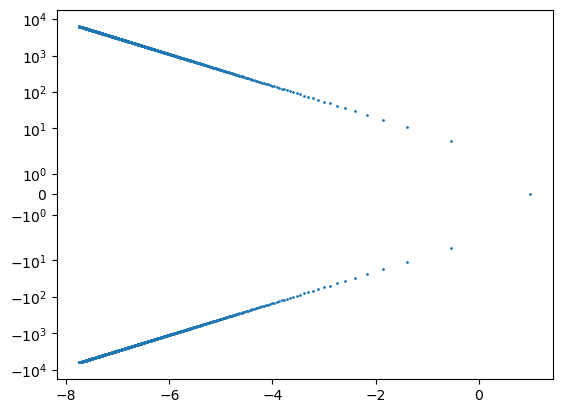

In [132]:
fig, ax = plt.subplots()
ax.set_yscale("symlog")
ax.scatter(np.real(ws), np.imag(ws), s=1)

In [133]:
def make_function(_as):
    def function(x):
        return np.real(_as * np.exp(x * (ws - 1.0))).sum()
    
    def d_function(x):
        return np.real(_as * (ws - 1.0) * np.exp(x * (ws - 1.0))).sum()
    return function, d_function

In [168]:
As = np.random.uniform(-100, 100, size=N) + 1j * np.random.uniform(-100, 100, size=N)
Ass = np.array(As.tolist() + [0] + As.tolist())
fun, dfun = make_function(Ass)

In [218]:
xs = np.linspace(1, 100, 10001)
ys = np.array([fun(x/1.532) for x in xs])
delta_ys = np.array([fun((x+1)/1.532) - fun((x)/1.532) for x in xs])
diff_ys = np.array([dfun(x) for x in xs])

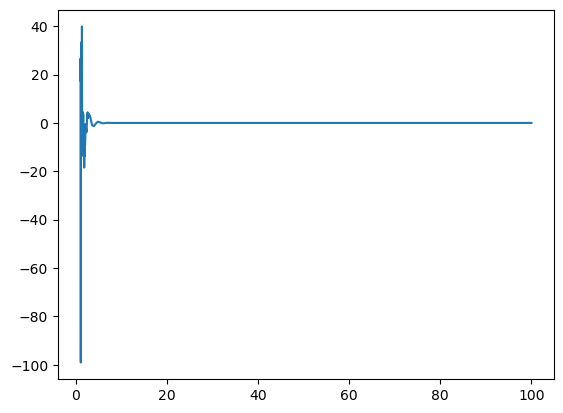

In [219]:
plt.plot(xs, ys)

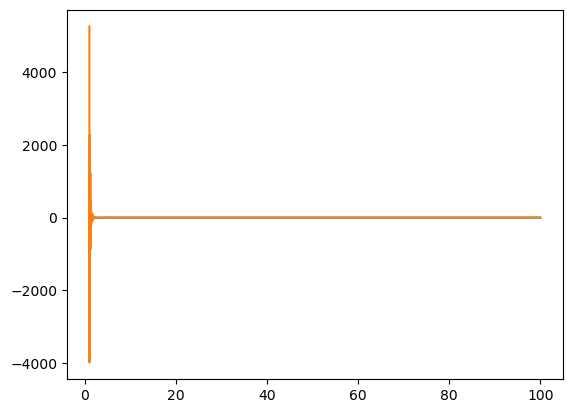

In [221]:
plt.plot(xs, delta_ys)
plt.plot(xs, diff_ys)
plt.xlim(-1, 1)